## Câu hỏi 1: Đánh giá tỷ lệ ghế nghị sĩ quốc hội do phụ nữ nắm giữ ở các nước trên thế giới

### 1.1. Mục tiêu phân tích

Đánh giá bức tranh toàn cảnh về sự phân bố tỷ lệ ghế nghị sĩ quốc hội do phụ nữ nắm giữ trên phạm vi toàn cầu vào năm 2020, đồng thời so sánh xu hướng thay đổi của chỉ số này tại 6 quốc gia tiêu biểu đại diện cho các châu lục (Rwanda, Thụy Điển, Mỹ, Việt Nam, Nhật Bản, Nigeria) trong giai đoạn 2000 - 2024. 

Việc kết hợp giữa góc nhìn không gian (bản đồ toàn cầu) và góc nhìn thời gian (xu hướng 24 năm) sẽ giúp ta đánh giá một cách toàn diện và đa chiều nhất về sự tham gia của phụ nữ trong lĩnh vực chính trị trên thế giới nói chung và các quốc gia được xem xét xu hướng nói riêng.

### 1.2. Trường dữ liệu được sử dụng 

**`SG.GEN.PARL.ZS` - Proportion of seats held by women in national parliaments (%)**
* Chỉ số này đo lường tỷ lệ phần trăm số ghế mà phụ nữ nắm giữ trong quốc hội đơn viện (Single chamber) hoặc tại Hạ viện (Lower chamber) đối với hệ thống lưỡng viện, ví dụ ở Việt Nam sẽ là tỷ lệ phần trăm thành viên nữ trong Quốc hội Việt Nam. Dữ liệu do *Liên minh Nghị viện Thế giới (IPU)* cung cấp.
* Phương pháp tính: **[Tổng số ghế do phụ nữ nắm giữ trong Hạ viện/Quốc hội] / [Tổng số ghế của Hạ viện/Quốc hội] * 100**
* Chỉ số này phản ánh mức độ tham gia chính trị của phụ nữ trong từng quốc gia khác nhau.
* **Lưu ý:**  Chỉ số này **không** bao gồm số ghế ở Thượng viện (Upper house) và chính quyền địa phương.


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # Import thêm thư viện vẽ bản đồ

# Cài đặt tham số đồ họa
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# 1. Đọc dữ liệu
DATA_PATH = 'data3/dataset.csv' # Nhớ đổi lại đường dẫn nếu cần
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# 2. Xử lý dữ liệu định dạng Wide to Long cho toàn cầu
year_cols =[c for c in df_raw.columns if c.startswith('20') and c.endswith(']')]
parl_all = df_raw[df_raw['Series Code'] == 'SG.GEN.PARL.ZS'].copy()

parl_long = parl_all.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw', value_name='Value'
)
parl_long['Year'] = parl_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
parl_long['Value'] = pd.to_numeric(parl_long['Value'], errors='coerce')

# 3. Lọc riêng dữ liệu cho 6 quốc gia Case Study (Line Chart)
SELECTED_COUNTRIES = ['RWA', 'NGA', 'SWE', 'USA', 'VNM', 'JPN']
parl_case_study = parl_long[(parl_long['Country Code'].isin(SELECTED_COUNTRIES)) & (parl_long['Year'] <= 2024)].copy()

### 1.3. Phân tích chi tiết

**1.3.1. Biểu đồ 1: Bản đồ phân bố toàn cầu**

**Lý do chọn biểu đồ:** Để có cái nhìn toàn cảnh về sự phân bố địa lý của tỷ lệ nữ nghị sĩ trên thế giới, Choropleth Map là lựa chọn tối ưu. Biểu đồ này giúp người xem ngay lập tức nhận diện được các khu vực dẫn đầu (màu đậm) và các vùng tụt hậu (màu nhạt) thông qua cường độ màu sắc, từ đó phát hiện ra sự phân hóa giữa các châu lục.

In [5]:
# === BIỂU ĐỒ 1: CHOROPLETH MAP ===
# Lọc dữ liệu năm 2022 để vẽ bản đồ (Năm gần nhất có độ phủ dữ liệu toàn cầu tốt nhất)
df_map = parl_long[parl_long['Year'] == 2022].dropna(subset=['Value'])

fig = px.choropleth(
    df_map, 
    locations="Country Code", 
    color="Value", 
    hover_name="Country Name",
    color_continuous_scale="Reds", 
    title="Heatmap theo quốc gia: Tỷ lệ ghế Quốc hội do phụ nữ nắm giữ (2022)"
)

fig.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0},
    coloraxis_colorbar=dict(title="value"),
    geo=dict(
        showland=True,
        landcolor="lightgray"  
    )
)

fig.show()


Dựa vào sắc độ trên bản đồ, ta có thể quan sát thấy có sự phân hóa nhất định trên toàn cầu:
* Các khu vực dẫn đầu (Màu đỏ sẫm - trên 40%): Nổi bật nhất là sự thống trị của khu vực Châu Mỹ Latinh (Mexico, Argentina, Cuba, Nicaragua), Bắc Âu (Thụy Điển, Na Uy, Phần Lan) và một số ít quốc gia tại Châu Phi cận Sahara (Rwanda, Nam Phi). Đây là những điểm sáng của thế giới trong việc trao quyền cho nữ giới.
* Các khu vực tụt hậu (Màu trắng/nhạt - dưới 15%): Tập trung đậm đặc tạo thành một vành đai kéo dài từ khu vực Trung Đông, Bắc Phi sang phần lớn Đông Á và Nam Á. 
* Các khu vực màu xám là các quốc gia không có số liệu, do nhóm em chỉ lấy dữ liệu cho 100 nước tiêu biểu.

**1.3.2. Biểu đồ 2:** Biểu đồ đường (line chart), phân màu theo quốc gia.

Sau khi nhìn bức tranh không gian toàn cảnh, nhóm sử dụng multi-line chart để đi sâu vào phân tích vi mô. Biểu đồ này giúp so sánh tốc độ thay đổi (độ dốc) qua 24 năm của 6 quốc gia mang tính đại diện cho các châu lục khác nhau.

**Lý do chọn biểu đồ**: Để theo dõi xu hướng thay đổi liên tục qua các năm của nhiều đối tượng cùng lúc, nhóm em chọn dùng **biểu đồ đường đa biến (multi-line chart)**. Nó giúp ta dễ dàng so sánh độ dốc (tốc độ tăng trưởng) và vị thế của các quốc gia với nhau.

In [29]:
# Loc bo gia tri thieu de ve bieu do (imputation tuy bien)
# Chi dung imputation linear cho viec ve, khong thay doi du lieu goc
parl_clean = parl_case_study.copy()

# Loc nhung nam/quoc gia co du lieu
parl_with_data = parl_clean.dropna(subset=['Value']).copy()

print(f"So gia tri hop le: {len(parl_with_data)}")
print(f"Nam co du lieu: {sorted(parl_with_data['Year'].unique())}")
print(f"So gia tri thieu (nam/quoc gia): {parl_clean['Value'].isna().sum()}")

So gia tri hop le: 149
Nam co du lieu: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
So gia tri thieu (nam/quoc gia): 1


In [30]:
# tim o gia tri bi thieu
parl_clean[parl_clean['Value'].isna()]

,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year
106,United States,USA,Proportion of seats held by women in national ...,SG.GEN.PARL.ZS,2000 [YR2000],NaN,2000


Vì dữ liệu chỉ bị thiếu chỉ 1 giá trị thuộc nước Mỹ vào năm đầu tiên trong các năm ta muốn khảo sát nên nhóm em sẽ để trống ô dữ liệu đó mà không xử lý điền khuyết gì thêm.

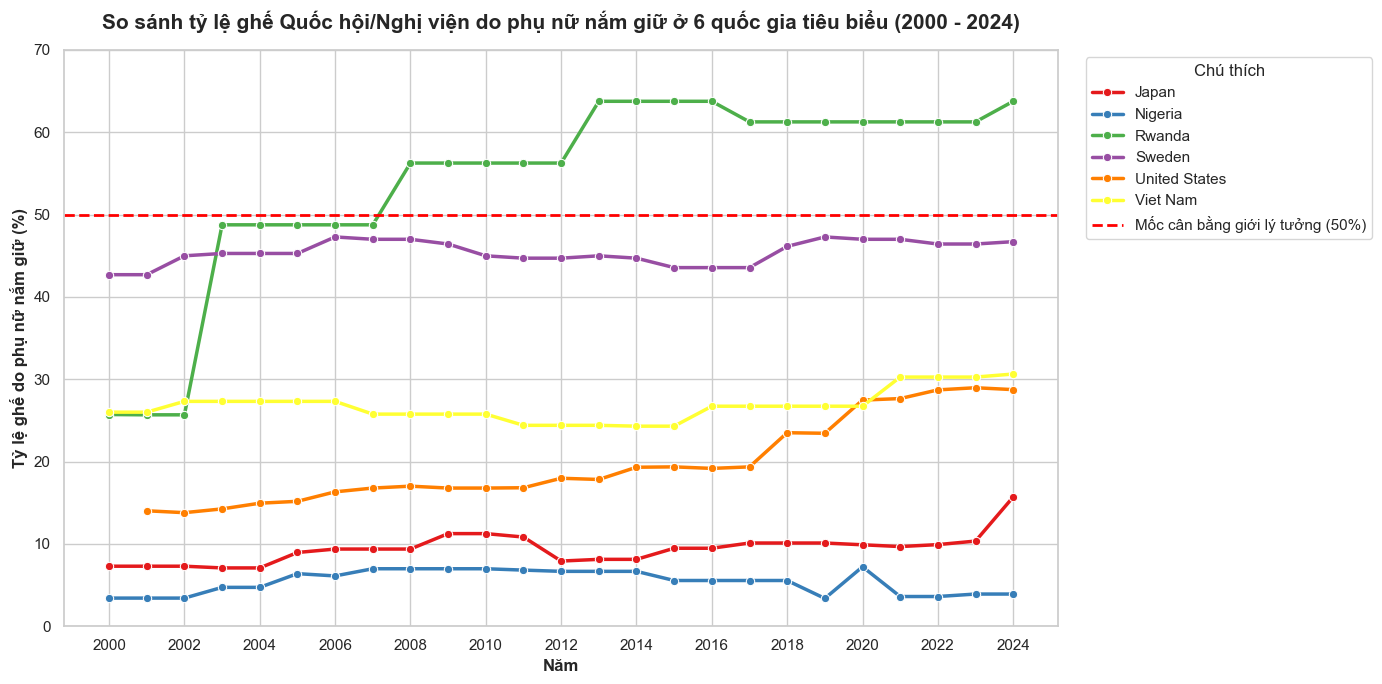

In [31]:
# === BIỂU ĐỒ 1: LINE CHART ===
plt.figure(figsize=(14, 7))

# Vẽ line chart
sns.lineplot(
    data=parl_clean,
    x='Year', y='Value',
    hue='Country Name',
    marker='o', markersize=6,
    palette='Set1', # Dùng Set1 để màu sắc tương phản mạnh
    linewidth=2.5
)

# Thêm đường tham chiếu mốc 50%
plt.axhline(50, color='red', linestyle='--', linewidth=2, label='Mốc cân bằng giới lý tưởng (50%)')

# Trang trí biểu đồ
plt.title('So sánh tỷ lệ ghế Quốc hội/Nghị viện do phụ nữ nắm giữ ở 6 quốc gia tiêu biểu (2000 - 2024)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Năm', fontsize=12, fontweight='bold')
plt.ylabel('Tỷ lệ ghế do phụ nữ nắm giữ (%)', fontsize=12, fontweight='bold')

# Hiển thị số năm chẵn trên trục X cho dễ nhìn
plt.xticks(range(2000, 2025, 2))
plt.ylim(0, 70) # Mở rộng trục Y để không bị sát lề

# Custom Legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Chú thích', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

Dựa vào biểu đồ trên, nhóm em rút ra một số phân tích đối với 6 quốc gia như sau:

* **Đường của Rwanda là điểm nhấn nổi bật nhất của toàn bộ biểu đồ.** Bắt đầu ở mức khoảng hơn 25% năm 2000, Rwanda đã có một cú nhảy vọt thẳng đứng lên tiệm cận 50% vào năm 2003, và tiếp tục bứt phá lên mức cao nhất thế giới (trên 60%) từ năm 2013 đến nay. Rwanda là quốc gia duy nhất trong nhóm vượt lên trên mốc lý tưởng 50% (đường đứt nét màu đỏ). Nguyên nhân cốt lõi là do Hiến pháp mới năm 2003 của nước này đã quy định bắt buộc áp dụng chính sách "hạn ngạch giới tính" (gender quota) tối thiểu 30% cho nữ giới, biến một nước nghèo ở Châu Phi thành quốc gia dẫn đầu toàn cầu về tỷ lệ phụ nữ trong lập pháp ([nguồn tham khảo](https://www.sdg16.plus/policies/rwandas-30-percent-gender-quota-led-to-the-worlds-largest-share-of-women-in-government/)).

* **Đường của Sweden dao động đều đặn ở mức rất cao (45% - 47%) trong suốt 24 năm.** Điều này một phần cho thấy nền tảng văn hóa bình đẳng giới của nước này khá lý tưởng.

* **Việt Nam duy trì tỷ lệ rất tốt**, ổn định quanh mức 26%-27% trong thời gian dài và có xu hướng tăng vọt qua mốc 30% từ năm 2021. Đáng chú ý, Việt Nam đã vượt qua cường quốc như Mỹ trong suốt 2 thập kỷ (từ 2000 đến 2024) và chỉ mới bị tiệm cận lại gần đây. Điều này phản ánh tính hiệu quả thực tiễn trong công tác quy hoạch cán bộ nữ tại Việt Nam.

* Dù là cường quốc dân chủ phương Tây, **Mỹ có điểm xuất phát rất thấp (chỉ khoảng 14% vào năm 2001)**. Tuy nhiên, đường biểu diễn cho thấy Mỹ có tốc độ tăng trưởng (độ dốc) tốt nhất và ổn định nhất, tịnh tiến liên tục để đạt mức xấp xỉ 29% vào năm 2024. Dù vậy, con số này vẫn còn cách rất xa chuẩn cân bằng 50%.

* **Đường biểu diễn của Nhật Bản nằm ở khu vực đáy biểu đồ, gần như đi ngang dưới mốc 11% trong suốt hơn 20 năm.** Dù có sự tăng vọt nhẹ lên mức khoảng 15% vào năm 2024, biểu đồ thể hiện rằng mức độ tham gia của phụ nữ vào cơ quan lập pháp có sự lệch pha so với sự phát triển kinh tế vượt bậc của nước này.

* **Đường biểu diễn của Nigeria luôn nằm ở vị trí thấp nhất trong cả 5 quốc gia (chỉ dao động từ khoảng 3% đến 7%).** Đáng quan ngại hơn, biểu đồ không cho thấy xu hướng tăng mà liên tục trồi sụt, thậm chí rớt xuống mức đáy (dưới 5%) vào năm 2024. 

### 1.4. Nhận xét chung và hạn chế

**1.4.1. Nhận xét chung**

Các biểu đồ trên cho thấy **sự giàu có về kinh tế không tự động mang lại quyền lực chính trị cho phụ nữ**. 

* Mỹ và Nhật Bản là các siêu cường kinh tế nhưng lại tụt hậu hoặc mất rất nhiều thời gian để cải thiện chỉ số này.
* Ngược lại, một quốc gia đang phát triển như Việt Nam lại duy trì được tỷ lệ cao nhờ sự can thiệp tốt từ cấu trúc thể chế chính trị.
* Tuy nhiên, trường hợp của Nigeria cũng cho thấy: Không phải nước đang phát triển nào cũng làm tốt điều này.
* Việc can thiệp bằng thể chế pháp lý (cụ thể là Luật hạn ngạch (gender quota) như Rwanda áp dụng) là một con "đường tắt" để thiết lập ngay lập tức sự cân bằng quyền lực và phá vỡ các định kiến truyền thống.

Ta có thể kết luận một phần rằng *bình đẳng giới trong chính trị không phụ thuộc vào quy mô GDP của quốc gia*.

**1.4.2. Hạn chế của phân tích**

* Chỉ số `SG.GEN.PARL.ZS` của World Bank **chỉ thống kê tỷ lệ ghế tại Hạ viện (Lower House) hoặc Quốc hội đơn viện (Single House)**. Nó hoàn toàn bỏ qua Thượng viện (Upper House), các vị trí hành pháp cốt lõi (Tổng thống, Thủ tướng, Bộ trưởng), và chính quyền địa phương (Hội đồng nhân dân cấp cơ sở). Do đó tỷ lệ này chưa phản ánh toàn diện 100% quyền lực chính trị thực tế của phụ nữ. Một quốc gia có thể có nhiều nữ nghị sĩ nhưng lại không có nữ bộ trưởng nào.
* Số lượng ghế dành cho phụ nữ trong quốc hội **chưa thể thể hiện chính xác tiếng nói của họ trong bộ máy nhà nước**.
* Các quốc gia được xét ở trên cũng **chưa thể đại diện cho toàn khu vực của họ** (ví dụ như hai nước Rwanda và Nigeria đều nằm ở khu vực Châu Phi nhưng có những số liệu trái ngược hoàn toàn). Những kết luận rút ra mang **tính chất tham chiếu đặc thù thay vì quy luật chung cho mọi quốc gia**.
* Mặc dù có thể thấy Rwanda áp dụng hạn ngạch về giới tính thành công và trở thành nước có tỷ lệ phụ nữ trong Nghị viện/Quốc hội cao nhất thế giới, nhưng *liệu vấn nạn về phân biệt giới ở nước này đã được giải quyết triệt để hay chưa? Hay chỉ mới giải quyết được bề nổi?* Thầy/Cô/Các bạn nếu muốn tìm hiểu thêm có thể tham khảo [bài viết này](https://www.npr.org/sections/goatsandsoda/2016/07/29/487360094/invisibilia-no-one-thought-this-all-womans-debate-team-could-crush-it) 

## Câu hỏi 2: Đánh giá mối tương quan giữa tỷ lệ nữ nghị sĩ quốc hội và mức độ đầu tư cho giáo dục, y tế

### 2.1. Mục tiêu phân tích

Đo lường và phân tích mức độ tương quan giữa Tỷ lệ ghế nghị sĩ quốc hội do phụ nữ nắm giữ với Tỷ trọng chi tiêu của chính phủ cho lĩnh vực y tế và giáo dục (% GDP) trên phạm vi toàn cầu vào năm 2020. Nhóm em chọn năm 2020 là vì đây là mốc gần nhất có số liệu ở nhiều quốc gia cho phần này (thật ra là không quá ít chứ cũng chưa đủ nhiều). 

Mục tiêu này được đặt ra để kiểm chứng giả thuyết: *"Liệu các quốc gia có sự tham gia chính trị của phụ nữ cao hơn có xu hướng ưu tiên ngân sách cho các chính sách an sinh xã hội (phát triển con người) tốt hơn hay không?"*

### 2.2. Trường dữ liệu được sử dụng

**`SG.GEN.PARL.ZS` - Proportion of seats held by women in national parliaments (%)**

(Đã mô tả trước đó)

**`SE.XPD.TOTL.GD.ZS` - Government expenditure on education, total (% of GDP)**
* Chỉ số này đo lường tổng chi tiêu chung của chính phủ (bao gồm trung ương, địa phương và các quỹ xã hội) dành cho giáo dục, thể hiện dưới dạng tỷ lệ phần trăm so với Tổng sản phẩm quốc nội (GDP). Dữ liệu do *Viện Thống kê UNESCO (UIS)* cung cấp.
* Phương pháp tính: **[Tổng chi tiêu công cho giáo dục ở tất cả các cấp học] / [Tổng sản phẩm quốc nội (GDP)] * 100**
* Chỉ số này phản ánh mức độ cam kết và sự ưu tiên của chính phủ một quốc gia đối với việc phát triển giáo dục và nguồn vốn con người so với quy mô của nền kinh tế.
* **Lưu ý:** Chỉ số này chỉ tính **chi tiêu công** (ngân sách từ thuế nhà nước), hoàn toàn không bao gồm chi tiêu tư nhân (tiền học phí do các hộ gia đình tự đóng cho con cái).

**`SH.XPD.GHED.GD.ZS` - Domestic general government health expenditure (% of GDP)**
* Chỉ số này đo lường tỷ trọng ngân sách y tế công cộng có nguồn gốc từ nguồn thu nội địa (thuế, phí) của chính phủ so với quy mô nền kinh tế (GDP). Dữ liệu do *Tổ chức Y tế Thế giới (WHO)* cung cấp.
* Phương pháp tính: **[Tổng chi tiêu y tế của chính phủ từ nguồn thu nội địa] / [Tổng sản phẩm quốc nội (GDP)] * 100**
* Chỉ số này phản ánh mức độ ưu tiên và khả năng tự chủ tài chính của một quốc gia trong việc đảm bảo an sinh sức khỏe cơ bản cho người dân.
* **Lưu ý:** Từ "Domestic" (nội địa) mang ý nghĩa **loại trừ** nguồn vốn viện trợ y tế từ nước ngoài hay từ các tổ chức quốc tế.

In [8]:
# === CAU HOI 2: TUONG QUAN GIUA TY LE NU NGHI SI VA DAU TU Y TE, GIAO DUC ===

# 1. Khai báo danh sách các chỉ số cần thiết
INDICATORS = {
    'SG.GEN.PARL.ZS': 'Women_in_Parliament',
    'SE.XPD.TOTL.GD.ZS': 'Edu_Expenditure',
    'SH.XPD.GHED.GD.ZS': 'Health_Expenditure'
}

# 2. Lọc dữ liệu từ df_raw (Lấy dữ liệu toàn cầu, không giới hạn 5 nước)
# Ta chọn năm 2020 làm năm phân tích vì dữ liệu chi tiêu công thường có độ trễ báo cáo
TARGET_YEAR = '2020 [YR2020]'

corr_df = df_raw[df_raw['Series Code'].isin(INDICATORS.keys())].copy()

# 3. Giữ lại các cột quan trọng và đổi tên cột năm 2020 thành 'Value'
corr_df = corr_df[['Country Name', 'Country Code', 'Series Code', TARGET_YEAR]]
corr_df.rename(columns={TARGET_YEAR: 'Value'}, inplace=True)

# Chuyển đổi kiểu dữ liệu (từ string sang float, gán NaN cho các giá trị '..')
corr_df['Value'] = pd.to_numeric(corr_df['Value'], errors='coerce')

# 4. Chuyển đổi cấu trúc bảng (Pivot from Long to Wide) để tính tương quan
# Mỗi quốc gia là 1 dòng, 3 chỉ số là 3 cột
pivot_df = corr_df.pivot(index=['Country Name', 'Country Code'], 
                         columns='Series Code', 
                         values='Value').reset_index()

# Đổi mã Series Code thành tên dễ hiểu
pivot_df.rename(columns=INDICATORS, inplace=True)

# 5. Xử lý dữ liệu thiếu (Data Cleansing)
# Trong phân tích tương quan Scatter, ta bắt buộc phải loại bỏ các quốc gia bị thiếu dữ liệu ở bất kỳ cột nào
corr_clean = pivot_df.dropna(subset=['Women_in_Parliament', 'Edu_Expenditure', 'Health_Expenditure']).copy()

print(f"Số lượng quốc gia có đầy đủ số liệu cho cả 3 chỉ số vào năm 2020: {len(corr_clean)} quốc gia")
corr_clean.head()

Số lượng quốc gia có đầy đủ số liệu cho cả 3 chỉ số vào năm 2020: 100 quốc gia


Series Code,Country Name,Country Code,Edu_Expenditure,Women_in_Parliament,Health_Expenditure
1,Algeria,DZA,6.193917,25.757576,3.311859
2,Angola,AGO,2.667447,30.000000,1.460554
3,Argentina,ARG,5.276900,40.856031,6.990576
4,Armenia,ARM,2.705560,23.484848,2.356737
5,Australia,AUS,5.386250,30.463576,7.852866


### 2.3. Phân tích chi tiết

**Biểu đồ:** Biểu đồ phân tán (scatter plot) kết hợp đường xu hướng hồi quy.

Ở phần này nhóm em sẽ vẽ 2 biểu đồ phân tán:
* Biểu đồ thể hiện tương quan giữa *Tỷ lệ nữ nghị sĩ* và *Chi tiêu của Chính phủ cho giáo dục*.
* Biểu đồ thể hiện tương quan giữa *Tỷ lệ nữ nghị sĩ* và *Chi tiêu của Chính phủ cho y tế*.

**Lý do chọn biểu đồ**: 
Ở phần này ta cần xem xét mối tương quan giữa hai biến số định lượng (*Tỷ lệ nữ nghị sĩ* vs. *Chi tiêu của Chính phủ*), nên nhóm em sẽ sử dụng **Biểu đồ phân tán (scatter plot) kết hợp đường xu hướng hồi quy** để biểu diễn dữ liệu. 
Đường xu hướng sẽ phần nào cho chúng ta biết mối quan hệ là đồng biến (đi lên), nghịch biến (đi xuống) hay không có tương quan (đường nằm ngang).

Để đánh giá mối quan hệ giữa hai biến định lượng trên biểu đồ phân tán thêm phần chính xác, nhóm em sử dụng các công cụ thống kê bên cạnh biểu đồ phân tán là:

**1. Hệ số tương quan Pearson ($r$):**
Hệ số Pearson đo lường mức độ tương quan tuyến tính giữa hai biến, có giá trị chạy từ $[-1, 1]$:
* Chiều hướng: 
  * $r > 0$: Tương quan thuận (biến này tăng thì biến kia cũng tăng).
  * $r < 0$: Tương quan nghịch (biến này tăng thì biến kia giảm).
  * $r = 0$: Không tương quan.
* Để tính hệ số này, nhóm sử dụng hàm `.corr()` của thư viện **Pandas** (`Series.corr()`). Mặc định, hàm này sử dụng thuật toán Pearson để tính toán ma trận tương quan một cách nhanh chóng.

**2. Đường thẳng hồi quy và dải tin cậy:**
* **Đường thẳng hồi quy (Đường màu đỏ):** Nhóm sử dụng hàm `regplot()` của thư viện **Seaborn**. Hàm này tích hợp sẵn thuật toán OLS của `scipy/statsmodels`, tự động khớp mô hình (fit model) và vẽ đường thẳng hồi quy lên không gian đồ thị.
* **Dải tin cậy (Vùng mờ xung quanh đường thẳng):** Thể hiện mức độ chắc chắn của đường xu hướng (thường ở mức 95%). Dải mờ càng hẹp chứng tỏ các điểm dữ liệu hội tụ rất sát đường hồi quy (độ tin cậy cao, ít nhiễu). 

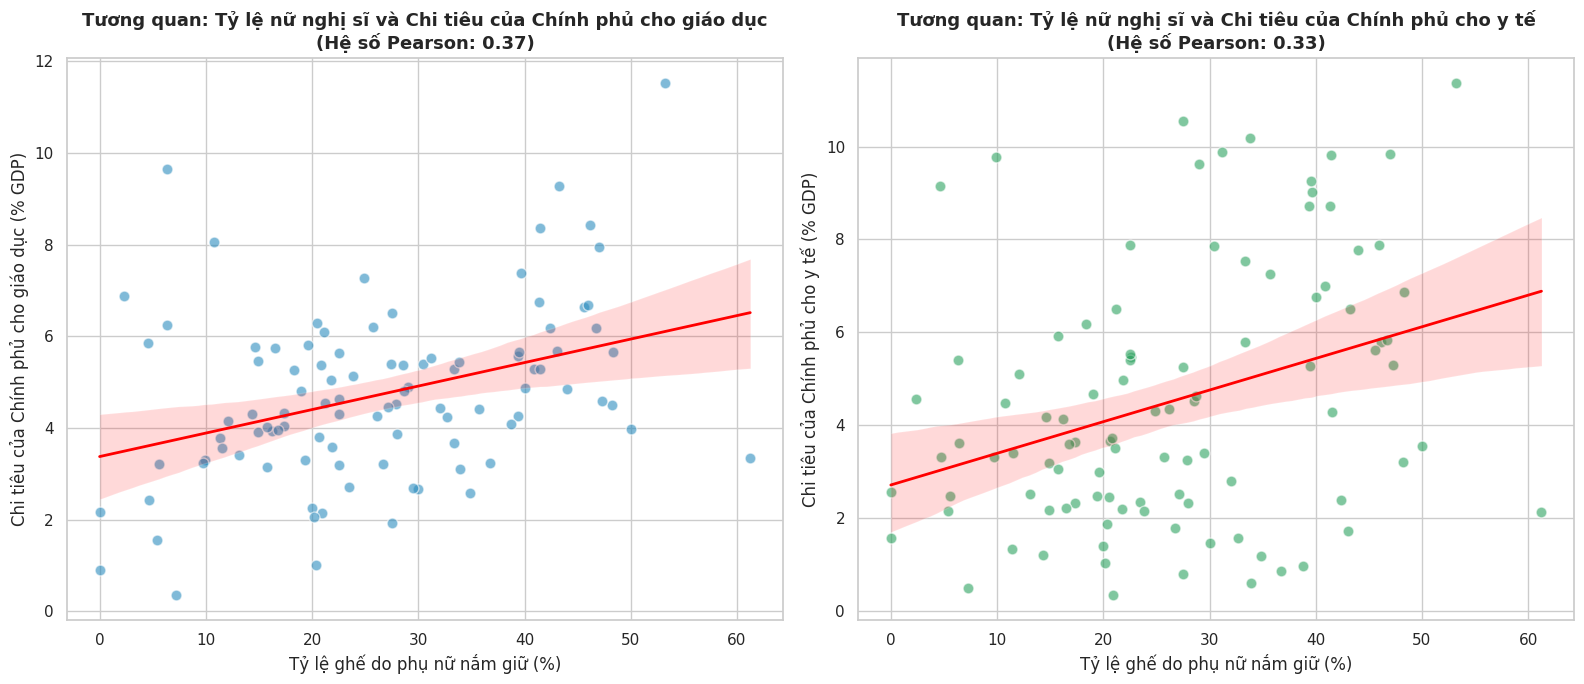

In [9]:
# === BIỂU ĐỒ 2: SCATTER PLOT & REGRESSION LINE ===
plt.figure(figsize=(16, 7))

# Tính toán hệ số tương quan Pearson
corr_edu = corr_clean['Women_in_Parliament'].corr(corr_clean['Edu_Expenditure'])
corr_health = corr_clean['Women_in_Parliament'].corr(corr_clean['Health_Expenditure'])

# Biểu đồ 1: Tương quan với Giáo dục
plt.subplot(1, 2, 1)
sns.regplot(data=corr_clean, x='Women_in_Parliament', y='Edu_Expenditure', 
            scatter_kws={'alpha':0.6, 'color':'#2b8cbe', 'edgecolor':'w', 's':60}, 
            line_kws={'color':'red', 'linewidth':2})
plt.title(f'Tương quan: Tỷ lệ nữ nghị sĩ và Chi tiêu của Chính phủ cho giáo dục\n(Hệ số Pearson: {corr_edu:.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Tỷ lệ ghế do phụ nữ nắm giữ (%)')
plt.ylabel('Chi tiêu của Chính phủ cho giáo dục (% GDP)')

# Biểu đồ 2: Tương quan với Y tế
plt.subplot(1, 2, 2)
sns.regplot(data=corr_clean, x='Women_in_Parliament', y='Health_Expenditure', 
            scatter_kws={'alpha':0.6, 'color':'#2ca25f', 'edgecolor':'w', 's':60}, 
            line_kws={'color':'red', 'linewidth':2})
plt.title(f'Tương quan: Tỷ lệ nữ nghị sĩ và Chi tiêu của Chính phủ cho y tế\n(Hệ số Pearson: {corr_health:.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Tỷ lệ ghế do phụ nữ nắm giữ (%)')
plt.ylabel('Chi tiêu của Chính phủ cho y tế (% GDP)')

plt.tight_layout()
plt.show()

Dựa vào 2 biểu đồ phân tán và đường hồi quy (màu đỏ) ở trên, nhóm em rút ra các phân tích như sau:
* Cả hai biểu đồ đều có đường xu hướng hướng lên trên và hệ số Pearson mang giá trị dương (lần lượt là 0.37 và 0.33), nghĩa là **có tồn tại xu hướng tương quan thuận**. Điều này bước đầu củng cố cho giả thuyết: *Tỷ lệ phụ nữ nắm giữ ghế trong Quốc hội/Nghị viện càng cao thì tỷ trọng ngân sách quốc gia (% GDP) chi cho an sinh xã hội (giáo dục và y tế) có xu hướng tăng theo.*
* Dù vậy **mức độ tương quan chỉ ở mức trung bình yếu và có độ phân tán cao**, các chấm dữ liệu (đại diện cho các quốc gia) phân tán rất rộng trên toàn bộ không gian đồ thị. Dải tin cậy (vùng màu hồng) khá rộng thể hiện mức độ biến thiên lớn giữa các quốc gia.
* So sánh giữa 2 lĩnh vực:
    * Với **giáo dục**: **Mối tương quan nhỉnh hơn một chút** (hệ số Pearson đạt 0.37). Dữ liệu có xu hướng tụ lại rõ hơn ở khu vực giữa (tỷ lệ nữ nghị sĩ từ 20-40% đi kèm với mức chi tiêu giáo dục 4-6% GDP).
    * Với **y tế**: **Mối tương quan yếu hơn** (hệ số Pearson đạt 0.33) và chứa rất nhiều outliers phá vỡ quy luật. Cụ thể, có những quốc gia tỷ lệ nữ nghị sĩ rất thấp (dưới 10%) nhưng lại chi ngân sách khổng lồ cho y tế (đạt 8-10% GDP); ngược lại, nhiều nước tỷ lệ nữ nghị sĩ đạt 20-40% nhưng chi tiêu y tế chỉ lẹt đẹt dưới 2-4% GDP.

### 2.4. Nhận xét chung và hạn chế

**2.4.1. Nhận xét chung**

Biểu đồ trên mang đến một cái nhìn thực tế và đa chiều về bài toán ngân sách quốc gia. Dữ liệu xác nhận rằng: **Sự hiện diện của phụ nữ trong nghị viện có mang lại tác động tích cực đến các chính sách phát triển con người, nhưng nó không phải là yếu tố duy nhất định hình ngân sách.**

Mức độ tương quan (0.33 và 0.37) cho thấy tiếng nói của các nữ nghị sĩ chỉ là một phần trong bức tranh tổng thể. Trên thực tế, ngân sách nhà nước (đặc biệt là cho y tế) chịu sự chi phối nặng nề bởi các yếu tố vĩ mô cấp bách hơn nhiều, ví dụ: cơ cấu dân số già hóa, rủi ro dịch bệnh, đặc thù của hệ thống bảo hiểm y tế từng nước...

**2.4.2. Hạn chế của phân tích**
 
* Biểu đồ chứng minh hai biến số này tăng cùng nhau, nhưng **chưa thể khẳng định 100% rằng nhờ có nữ nghị sĩ mà giáo dục/y tế được đầu tư thêm**. Có thể tồn tại những nguyên nhân đặc thù khác, ví dụ như sự phát triển chung của xã hội: Một xã hội văn minh, giàu có (như khối Bắc Âu) thì sẽ đồng thời làm tốt cả hai việc (vừa bầu nhiều phụ nữ vào nghị viện, vừa có đủ tiềm lực tài chính để chi nhiều cho an sinh xã hội).
* **Việc chi một số tiền lớn (% GDP) chưa chắc đã đem lại một nền giáo dục/y tế chất lượng** nếu quốc gia đó quản lý ngân sách kém hiệu quả. Tương tự, **số lượng nữ nghị sĩ nhiều không đồng nghĩa với việc họ thực sự có quyền quyết định phân bổ ngân sách**.

## Câu hỏi 3: Đánh giá mối tương quan giữa trình độ học vấn và nguồn lao động nữ giới

### 3.1. Mục tiêu phân tích

Đo lường mức độ tương quan giữa Tỷ lệ nữ giới nhập học Đại học/Cao đẳng và Tỷ lệ tham gia lực lượng lao động của nữ giới trên phạm vi toàn cầu vào năm 2020. 

Mục tiêu này được đặt ra theo dõi xem nếu càng nhiều phụ nữ có trình độ học vấn cao thì tỷ lệ mà họ xuất hiện trong lực lượng lao động sẽ thay đổi như thế nào.

### 3.2. Trường dữ liệu được sử dụng

**`SE.TER.ENRR.FE` - School enrollment, tertiary, female (% gross)**
* Chỉ số này đo lường tỷ lệ tổng số nữ sinh viên đăng ký học bậc giáo dục bậc cao (đại học, cao đẳng, chứng chỉ sau trung học), so với tổng dân số nữ nằm trong độ tuổi quy định chính thức của bậc học này (thường là nhóm 18-22 tuổi). Dữ liệu do *Viện Thống kê UNESCO (UIS)* cung cấp.
* Phương pháp tính: **[Tổng nữ sinh viên đang học Đại học/Cao đẳng ở mọi độ tuổi] / [Tổng dân số nữ trong độ tuổi học Đại học chính thức] * 100**
* Chỉ số này phản ánh năng lực đào tạo và mức độ tiếp cận tri thức bậc cao của lực lượng lao động nữ tại một quốc gia.
* **Lưu ý:** Vì đây là tỷ lệ gộp (Gross), tử số bao gồm sinh viên ở mọi độ tuổi (kể cả người học muộn, học văn bằng 2), trong khi mẫu số bị cố định ở một nhóm tuổi cụ thể. Do đó, tỷ lệ này hoàn toàn **có thể vượt quá 100%** ở các quốc gia phát triển.

**`SL.TLF.CACT.FE.ZS` - Labor force participation rate, female (% of female population ages 15+)**
* Chỉ số này đo lường tỷ lệ phụ nữ từ 15 tuổi trở lên đang hoạt động kinh tế (cung cấp sức lao động để sản xuất hàng hóa và dịch vụ trong một khoảng thời gian xác định). Dữ liệu là mô hình ước tính do *Tổ chức Lao động Quốc tế (ILO)* cung cấp.
* Phương pháp tính: **([Số phụ nữ đang có việc làm] + [Số phụ nữ thất nghiệp nhưng đang tìm việc]) / [Tổng dân số nữ từ 15 tuổi trở lên] * 100**
* Chỉ số này phản ánh mức độ phụ nữ trực tiếp tham gia và đóng góp vào nền kinh tế thị trường thay vì bị giữ lại ở khu vực kinh tế gia đình.
* **Lưu ý:** Khái niệm "Lực lượng lao động" (Labor Force) bao gồm cả những người đang tích cực tìm việc, nhưng **hoàn toàn không bao gồm** những phụ nữ làm công việc nội trợ toàn thời gian ở nhà (công việc phi chính thức không được trả lương).

In [10]:
# === CAU HOI 3: TUONG QUAN GIUA HOC VAN (DAI HOC) VA VIEC LAM CUA NU GIOI ===

# 1. Khai báo danh sách các chỉ số cần thiết
INDICATORS_Q3 = {
    'SE.TER.ENRR.FE': 'Female_Tertiary_Edu',
    'SL.TLF.CACT.FE.ZS': 'Female_Labor_Force'
}

# 2. Lọc dữ liệu từ df_raw cho năm 2020
TARGET_YEAR_Q3 = '2020 [YR2020]'

corr_df3 = df_raw[df_raw['Series Code'].isin(INDICATORS_Q3.keys())].copy()

# 3. Giữ lại các cột quan trọng và đổi tên cột
corr_df3 = corr_df3[['Country Name', 'Country Code', 'Series Code', TARGET_YEAR_Q3]]
corr_df3.rename(columns={TARGET_YEAR_Q3: 'Value'}, inplace=True)

# Chuyển đổi kiểu dữ liệu (từ string sang float, gán NaN cho các giá trị '..')
corr_df3['Value'] = pd.to_numeric(corr_df3['Value'], errors='coerce')

# 4. Chuyển đổi cấu trúc bảng (Pivot from Long to Wide)
pivot_df3 = corr_df3.pivot(index=['Country Name', 'Country Code'], 
                           columns='Series Code', 
                           values='Value').reset_index()

# Đổi mã Series Code thành tên dễ hiểu
pivot_df3.rename(columns=INDICATORS_Q3, inplace=True)

# 5. Xử lý dữ liệu thiếu (Data Cleansing)
# Bỏ qua các quốc gia thiếu 1 trong 2 chỉ số
corr_clean3 = pivot_df3.dropna(subset=['Female_Tertiary_Edu', 'Female_Labor_Force']).copy()

print(f"Số lượng quốc gia có đầy đủ số liệu cho cả 2 chỉ số vào năm 2020: {len(corr_clean3)} quốc gia")
corr_clean3.head()

Số lượng quốc gia có đầy đủ số liệu cho cả 2 chỉ số vào năm 2020: 87 quốc gia


Series Code,Country Name,Country Code,Female_Tertiary_Edu,Female_Labor_Force
0,Afghanistan,AFG,5.936540,16.474
1,Algeria,DZA,67.541850,13.206
3,Argentina,ARG,127.155376,46.486
4,Armenia,ARM,59.571208,54.317
5,Australia,AUS,130.225403,60.136


### 3.3. Phân tích chi tiết

**Biểu đồ:** Biểu đồ phân tán (scatter plot) kết hợp đường xu hướng hồi quy.

**Lý do chọn biểu đồ**: Tương tự như câu hỏi 2, để xem xét tương quan giữa hai biến định lượng (Tỷ lệ học đại học/cao đẳng vs Tỷ lệ tham gia nguồn lao động), nhóm em sẽ dùng **Biểu đồ phân tán (scatter plot)** để biểu diễn một cách trực quan và chính xác nhất. Biểu đồ này giúp ta không chỉ nhìn thấy xu hướng chung (qua đường hồi quy) mà còn dễ dàng phát hiện ra các "điểm dị biệt" (outliers) - tức là những quốc gia đi ngược lại với quy luật thông thường.

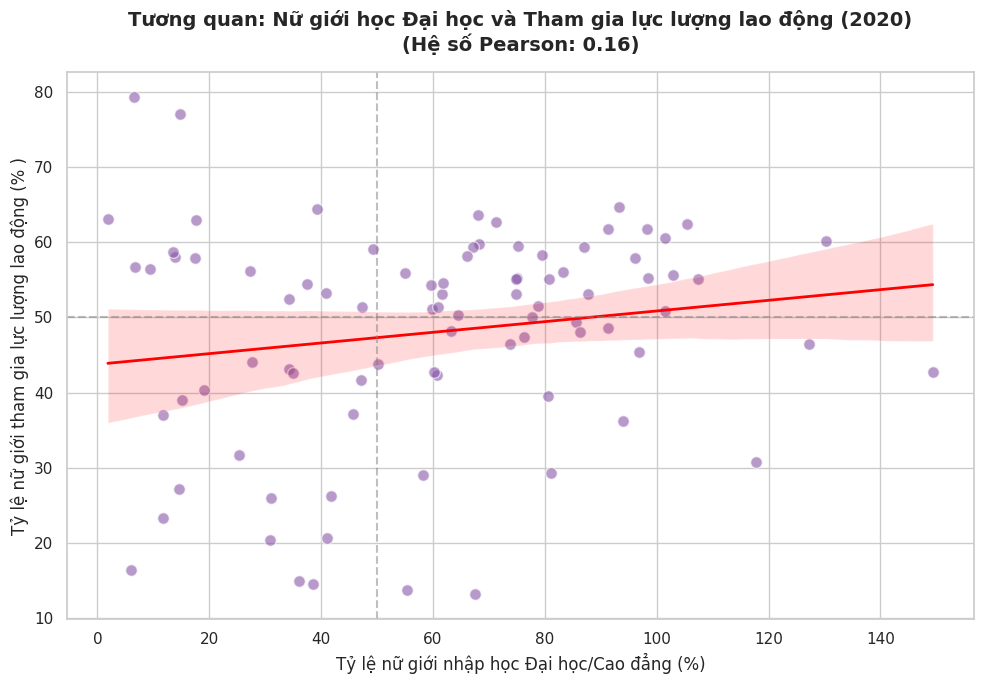

In [11]:
# === BIỂU ĐỒ 3: SCATTER PLOT & REGRESSION LINE ===
plt.figure(figsize=(10, 7))

# Tính toán hệ số tương quan Pearson
corr_edu_labor = corr_clean3['Female_Tertiary_Edu'].corr(corr_clean3['Female_Labor_Force'])

# Vẽ scatter plot với đường hồi quy
sns.regplot(data=corr_clean3, x='Female_Tertiary_Edu', y='Female_Labor_Force', 
            scatter_kws={'alpha':0.6, 'color':'#8856a7', 'edgecolor':'w', 's':70}, 
            line_kws={'color':'red', 'linewidth':2})

# Trang trí biểu đồ
plt.title(f'Tương quan: Nữ giới học Đại học và Tham gia lực lượng lao động (2020)\n(Hệ số Pearson: {corr_edu_labor:.2f})', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ nữ giới nhập học Đại học/Cao đẳng (%)', fontsize=12)
plt.ylabel('Tỷ lệ nữ giới tham gia lực lượng lao động (% )', fontsize=12)

# Thêm các đường line mốc tham chiếu để chia góc phần tư (Quadrant)
plt.axvline(50, color='gray', linestyle='--', alpha=0.5) # Mốc 50% học đại học
plt.axhline(50, color='gray', linestyle='--', alpha=0.5) # Mốc 50% đi làm

plt.tight_layout()
plt.show()

Dựa vào biểu đồ phân tán ở trên, nhóm em rút ra được các phân tích như sau:
* Với hệ số Pearson chỉ đạt 0.16, đường xu hướng hồi quy (màu đỏ) nằm gần như đi ngang cho thấy **mức độ tương quan cực kỳ yếu**. Các chấm dữ liệu phân tán lộn xộn trên toàn bộ không gian đồ thị thay vì bám sát vào đường xu hướng. Điều này phần nào chứng tỏ một sự thật rằng: **Tỷ lệ nữ giới nhập học đại học/cao đẳng cao không đồng nghĩa với việc họ sẽ tham gia vào lực lượng lao động nhiều hơn**.
* Dựa vào 2 đường tham chiếu nét đứt màu xám (mốc 50%), biểu đồ thể hiện sự phân hóa rõ rệt thành **4 thái cực**, trong đó có các điểm đáng chú ý sau:
    * Góc trái trên: Tồn tại một lượng lớn quốc gia có **tỷ lệ nữ đi học đại học rất thấp (chỉ từ 10-30%) nhưng tỷ lệ tham gia lao động lại cao chót vót (60-80%)**. Đây chủ yếu là các nền kinh tế nông nghiệp hoặc thu nhập thấp, nơi phụ nữ bắt buộc phải lao động chân tay để sinh tồn dù không có bằng cấp.
    * Góc phải dưới: Đáng chú ý nhất là khu vực này. Có rất nhiều quốc gia đạt **tỷ lệ nữ giới đi học đại học cực cao (60%, 80%, thậm chí vượt 100%) nhưng tỷ lệ đi làm lại nằm dưới mức 40%, thậm chí chỉ 15-20%**. Điều này cho thấy phụ nữ ở các quốc gia này được tiếp cận tri thức rất tốt, nhưng lại bị rào cản nào đó ngăn cấm bước ra ngoài làm việc.
    * Góc phải trên (trường hợp lý tưởng): Vẫn có một cụm các quốc gia **hội tụ đủ cả 2 yếu tố (học trên 50% và làm trên 50%)**. Đây thường là các quốc gia phát triển với hệ thống phúc lợi xã hội tốt.

### 3.4. Nhận xét chung và hạn chế

**3.4.1. Nhận xét chung**

Biểu đồ này đã phơi bày ra một **nghịch lý về học vấn** của nữ giới trên toàn cầu: *Bằng cấp đại học là điều kiện "cần" để nâng cao chất lượng nhân lực, nhưng hoàn toàn chưa "đủ" để giải phóng sức lao động của phụ nữ.*

Dữ liệu cho thấy tại rất nhiều quốc gia, dù hệ thống giáo dục cực kỳ cởi mở (nữ giới học đại học áp đảo), nhưng khi tốt nghiệp, họ lại biến mất khỏi thị trường lao động. Rất có thể những rào cản như: chế độ gia trưởng, định kiến tôn giáo, thiếu vắng cơ sở trông giữ trẻ, nền kinh tế không tạo ra đủ việc làm phù hợp... đã trói chân những người phụ nữ có trình độ cao. Đây là một sự lãng phí nguồn vốn con người khổng lồ đối với nền kinh tế.

**3.4.2. Hạn chế của phân tích**

Mặc dù biểu đồ đã phản ánh được một số nghịch lý, phân tích này vẫn vấp phải một số rào cản về mặt đặc tả dữ liệu:

* Chỉ số `SL.TLF.CACT.FE.ZS` trên trục Y bao gồm tất cả các hình thức lao động: từ CEO văn phòng cho đến lao động tự do, bán hàng rong, và làm nông nghiệp tự cung tự cấp. Do đó, ở các nước nghèo, **phụ nữ có tỷ lệ đi làm rất cao (góc trên bên trái biểu đồ) không có nghĩa là họ có công việc tốt hay bình đẳng giới cao, mà đơn thuần là sự ép buộc của hoàn cảnh kinh tế**. Điều này gây nhiễu lớn khi đem đi so sánh với tỷ lệ có bằng đại học.
* Trục X có xuất hiện các quốc gia vượt mốc 100% (thậm chí lên tới 140%). Đây là đặc điểm của **tỷ lệ gộp (gross enrollment)** (tính cả phụ nữ lớn tuổi đi học lại, học văn bằng 2, học muộn so với độ tuổi quy định). Điều này khiến cho dữ liệu không phản ánh chính xác 100% tỷ lệ thanh niên nữ đang học đại học đúng độ tuổi.